Consider the simple maze shown below.\
In each of the 47 states there are four actions, **up**, **down**, **right**, and **left**, which take the agent deterministically to the corresponding neighboring states, except when movement is blocked by an obstacle or the edge of the maze, in which case the agent remains where it is.\
Reward is zero on all transitions, except those into the goal state, on which it is +1. \
After reaching the goal state (**G**), the agent returns to the start state (**S**) to begin a new episode. \
This is a discounted, episodic task with $\gamma$ = 0.95.

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
h = 6
w = 9
start = (0, 3)
goal = (8, 5)
obstacle = [(2, 2), (2, 3), (2, 4), (5, 1), (7, 3), (7, 4), (7, 5)]
states = [(x, y) for x in range(w) for y in range(h) if (x, y) not in obstacle]
actions = [(1, 0), (0, 1), (-1, 0), (0, -1)]
gamma = 0.95
epsilon = 0.1
alpha = 0.5
T = 3
n = 50

In [3]:
def showPolicy(policy):
    # Create a grid to visualize the path
    grid = np.zeros((h, w), dtype=int)
    
    # Plot
    fig, ax = plt.subplots(figsize=(w, h))
    ax.set_xlim(-0.5, w - 0.5)
    ax.set_ylim(-0.5, h - 0.5)
    ax.set_aspect('equal')
    ax.set_xticks(range(w))
    ax.set_yticks(range(h))
    ax.grid(True)
    
    # Draw path on grid
    
    # Mark start and goal
    ax.plot(start[0], start[1], 'go', markersize=15, label='Start')
    ax.plot(goal[0], goal[1], 'r*', markersize=20, label='Goal')

    # Mark Obstacle
    xs = [grid[0] for grid in obstacle]
    ys = [grid[1] for grid in obstacle]
    ax.plot(xs, ys, 'ys', markersize=15, label='Obstacle' )
    
    # Draw policy arrows
    if policy is not None:
        for state in states:
            if state != goal:
                action = policy[state]
                x, y = state
                dx, dy = action
                ax.arrow(x, y, dx * 0.4, dy * 0.4, head_width=0.1, head_length=0.1, fc='k', ec='k')
    
    # Draw line connecting the path
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Maze')
    ax.legend()
    plt.show()

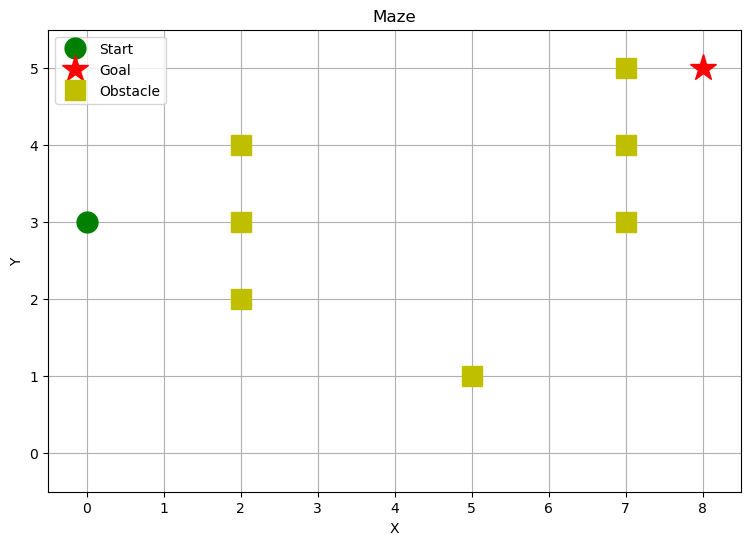

In [4]:
showPolicy(None)

In [5]:
def decideAction(Q, state, epsilon):
    sample = np.random.random()
    if sample < epsilon:
        # random
        return actions[np.random.choice([num for num in range(len(actions))])]
    else:
        # greedy
        maxQ = -1e6
        for action in actions:
            if Q[state][action] > maxQ:
                maxQ = Q[state][action]
                optimalAction = action
        return optimalAction

In [6]:
def takeAction(state, action):
    x, y = state
    dx, dy = action
    nx = x + dx
    nx = min(max(nx, 0), w - 1)
    ny = y + dy
    ny = min(max(ny, 0), h - 1)
    if (nx, ny) in obstacle:
        nx, ny = x, y
    if (nx, ny) == goal:
        reward = 1
    else:
        reward = 0
    return reward, (nx, ny)

In [7]:
Q = {state : {action : 0 for action in actions} for state in states}
memo = []
for t in range(T):
    currState = start
    while currState != goal:
        currAction = decideAction(Q, currState, epsilon / (t + 1))
        reward, nextState = takeAction(currState, currAction)
        optimalAction = decideAction(Q, nextState, -1)
        Q[currState][currAction] = Q[currState][currAction] + alpha * (reward + gamma * Q[nextState][optimalAction] - Q[currState][currAction])
        memo.append((currState, currAction, reward, nextState))
        currState = nextState
        for i in range(n):
            s, a, r, ns = memo[random.randint(0, len(memo) - 1)]
            oa = decideAction(Q, ns, -1)
            Q[s][a] = Q[s][a] + alpha * (r + gamma * Q[ns][oa] - Q[s][a])
        

In [8]:
policy = {}
for state in states:
    optimalAction = decideAction(Q, state, -1)
    policy[state] = optimalAction

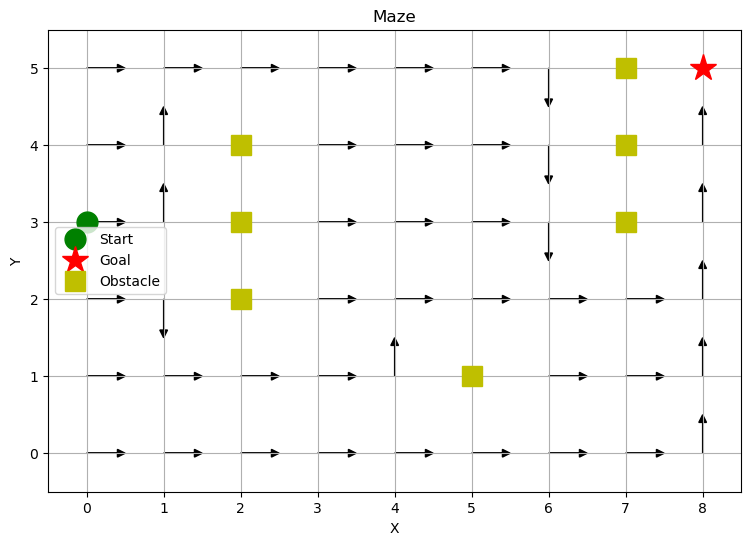

In [9]:
showPolicy(policy)